In [1]:
import numpy as np
import pandas as pd
import lightgbm as lgb

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")
print("LightGBM version:", lgb.__version__)

Libraries imported successfully!
LightGBM version: 4.7.0


In [2]:
import os

for filename in [
    "X_train_processed.pkl",
    "X_val_processed.pkl",
    "X_test_processed.pkl",
    "y_train.pkl",
    "y_val.pkl",
    "y_test.pkl"
]:
    path = "../data/" + filename
    
    print(
        filename,
        "->",
        os.path.getsize(path) / (1024 * 1024),
        "MB"
    )

X_train_processed.pkl -> 351.9174966812134 MB
X_val_processed.pkl -> 117.30598545074463 MB
X_test_processed.pkl -> 117.30789279937744 MB
y_train.pkl -> 5.631442070007324 MB
y_val.pkl -> 1.877640724182129 MB
y_test.pkl -> 1.8776788711547852 MB


In [3]:
with open("../data/X_train_processed.pkl", "rb") as f:
    header = f.read(32)

print(header)

b'\x80\x04\x95\xd6\x00\x00\x00\x00\x00\x00\x00\x8c\x13joblib.numpy_pickle'


In [4]:
import joblib

X_train_processed = joblib.load(
    "../data/X_train_processed.pkl"
)

X_val_processed = joblib.load(
    "../data/X_val_processed.pkl"
)

X_test_processed = joblib.load(
    "../data/X_test_processed.pkl"
)

y_train = joblib.load(
    "../data/y_train.pkl"
)

y_val = joblib.load(
    "../data/y_val.pkl"
)

y_test = joblib.load(
    "../data/y_test.pkl"
)

print("Data loaded successfully!")

print("Train:", X_train_processed.shape)
print("Validation:", X_val_processed.shape)
print("Test:", X_test_processed.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

Data loaded successfully!
Train: (184506, 250)
Validation: (61502, 250)
Test: (61503, 250)
y_train: (184506,)
y_val: (61502,)
y_test: (61503,)


In [5]:
print("Training missing values:",
      np.isnan(X_train_processed).sum())

print("Validation missing values:",
      np.isnan(X_val_processed).sum())

print("Test missing values:",
      np.isnan(X_test_processed).sum())

print("\nTarget distribution:")

print("Train:")
print(pd.Series(y_train).value_counts())

print("\nValidation:")
print(pd.Series(y_val).value_counts())

print("\nTest:")
print(pd.Series(y_test).value_counts())

Training missing values: 0
Validation missing values: 0
Test missing values: 0

Target distribution:
Train:
TARGET
0    169611
1     14895
Name: count, dtype: int64

Validation:
TARGET
0    56537
1     4965
Name: count, dtype: int64

Test:
TARGET
0    56538
1     4965
Name: count, dtype: int64


In [6]:
negative_samples = (y_train == 0).sum()
positive_samples = (y_train == 1).sum()

scale_pos_weight = negative_samples / positive_samples

print("Negative samples:", negative_samples)
print("Positive samples:", positive_samples)
print("Scale Pos Weight:", scale_pos_weight)

Negative samples: 169611
Positive samples: 14895
Scale Pos Weight: 11.38710976837865


In [7]:
import joblib

X_train_processed = joblib.load(
    "../data/X_train_final_processed.pkl"
)

X_val_processed = joblib.load(
    "../data/X_val_final_processed.pkl"
)

X_test_processed = joblib.load(
    "../data/X_test_final_processed.pkl"
)

y_train = joblib.load(
    "../data/y_train_final.pkl"
)

y_val = joblib.load(
    "../data/y_val_final.pkl"
)

y_test = joblib.load(
    "../data/y_test_final.pkl"
)

print("FINAL data loaded successfully!")

print("Train:", X_train_processed.shape)
print("Validation:", X_val_processed.shape)
print("Test:", X_test_processed.shape)

FINAL data loaded successfully!
Train: (184506, 422)
Validation: (61502, 422)
Test: (61503, 422)


In [8]:
lgb_model = lgb.LGBMClassifier(
    objective="binary",

    n_estimators=2000,
    learning_rate=0.03,

    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=1.0,

    scale_pos_weight=scale_pos_weight,

    random_state=42,
    n_jobs=-1
)

print("LightGBM model created!")

LightGBM model created!


In [9]:
lgb_model.fit(
    X_train_processed,
    y_train,

    eval_set=[
        (X_val_processed, y_val)
    ],

    eval_metric="auc",

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            verbose=True
        )
    ]
)

/Users/arnav/Desktop/AI-Finance-Research/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14895, number of negative: 169611
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.063242 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 30836
[LightGBM] [Info] Number of data points in the train set: 184506, number of used features: 406
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2]	valid_0's auc: 0.718384	valid_0's binary_logloss: 0.276788


,learning_rate,0.03
,n_estimators,2000
,objective,'binary'
,min_child_samples,50
,subsample,0.8
,colsample_bytree,0.8
,reg_alpha,0.1
,reg_lambda,1.0
,random_state,42
,n_jobs,-1
,scale_pos_weight,np.float64(11.38710976837865)


In [10]:
y_val_proba = lgb_model.predict_proba(
    X_val_processed
)[:, 1]

print("Validation predictions generated!")

Validation predictions generated!


In [11]:
val_roc_auc = roc_auc_score(
    y_val,
    y_val_proba
)

val_pr_auc = average_precision_score(
    y_val,
    y_val_proba
)

print("LightGBM Validation ROC-AUC:", val_roc_auc)
print("LightGBM Validation PR-AUC:", val_pr_auc)
print("Best iteration:", lgb_model.best_iteration_)

LightGBM Validation ROC-AUC: 0.7183835569292099
LightGBM Validation PR-AUC: 0.18533809583893565
Best iteration: 2


In [12]:
lgb_model_unweighted = lgb.LGBMClassifier(
    objective="binary",

    n_estimators=2000,
    learning_rate=0.03,

    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=1.0,

    # NO scale_pos_weight

    random_state=42,
    n_jobs=-1
)

print("Unweighted LightGBM model created!")

Unweighted LightGBM model created!


In [13]:
lgb_model_unweighted.fit(
    X_train_processed,
    y_train,

    eval_set=[
        (X_val_processed, y_val)
    ],

    eval_metric="auc",

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            verbose=True
        )
    ]
)

/Users/arnav/Desktop/AI-Finance-Research/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14895, number of negative: 169611
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.091752 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 30836
[LightGBM] [Info] Number of data points in the train set: 184506, number of used features: 406
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[731]	valid_0's auc: 0.781644	valid_0's binary_logloss: 0.23853


,learning_rate,0.03
,n_estimators,2000
,objective,'binary'
,min_child_samples,50
,subsample,0.8
,colsample_bytree,0.8
,reg_alpha,0.1
,reg_lambda,1.0
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'


In [14]:
y_val_proba_unweighted = (
    lgb_model_unweighted.predict_proba(
        X_val_processed
    )[:, 1]
)

roc_auc_unweighted = roc_auc_score(
    y_val,
    y_val_proba_unweighted
)

pr_auc_unweighted = average_precision_score(
    y_val,
    y_val_proba_unweighted
)

print("Unweighted LightGBM ROC-AUC:",
      roc_auc_unweighted)

print("Unweighted LightGBM PR-AUC:",
      pr_auc_unweighted)

print("Best iteration:",
      lgb_model_unweighted.best_iteration_)

Unweighted LightGBM ROC-AUC: 0.7816442105367781
Unweighted LightGBM PR-AUC: 0.28010086991282546
Best iteration: 731


In [15]:
feature_importance = pd.DataFrame({
    "Feature": X_train_processed.columns
        if hasattr(X_train_processed, "columns")
        else range(X_train_processed.shape[1]),
    "Importance": lgb_model_unweighted.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print("Top 30 features:")
display(feature_importance.head(30))

Top 30 features:


,Feature,Importance
27,27,594
28,28,565
29,29,535
9,9,420
3,3,416
107,107,378
77,77,376
108,108,374
8,8,347
177,177,344


In [16]:
import joblib

preprocessor = joblib.load(
    "../data/preprocessor.pkl"
)

print("Preprocessor loaded successfully!")

Preprocessor loaded successfully!


In [17]:
feature_names = preprocessor.get_feature_names_out()

print("Number of feature names:", len(feature_names))
print("Processed feature count:", X_train_processed.shape[1])

Number of feature names: 250
Processed feature count: 422


In [18]:
final_feature_names = joblib.load(
    "../data/final_feature_names.pkl"
)

print("Feature names loaded:", len(final_feature_names))
print("Processed features:", X_train_processed.shape[1])

Feature names loaded: 422
Processed features: 422


In [19]:
feature_importance = pd.DataFrame({
    "Feature": final_feature_names,
    "Importance": lgb_model_unweighted.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance.head(30))

,Feature,Importance
0,num__EXT_SOURCE_1,594
1,num__EXT_SOURCE_2,565
2,num__EXT_SOURCE_3,535
3,num__DAYS_ID_PUBLISH,420
4,num__AMT_ANNUITY,416
5,num__ANNUITY_INCOME_RATIO,378
6,num__DAYS_LAST_PHONE_CHANGE,376
7,num__CREDIT_GOODS_RATIO,374
8,num__DAYS_REGISTRATION,347
9,num__POS_INSTALMENT_FUTURE_MEAN,344


In [20]:
lgb_model_63 = lgb.LGBMClassifier(
    objective="binary",

    n_estimators=2000,
    learning_rate=0.03,

    num_leaves=63,
    max_depth=-1,
    min_child_samples=50,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=1.0,

    random_state=42,
    n_jobs=-1
)

print("LightGBM 63-leaf model created!")

LightGBM 63-leaf model created!


In [21]:
lgb_model_63.fit(
    X_train_processed,
    y_train,

    eval_set=[
        (X_val_processed, y_val)
    ],

    eval_metric="auc",

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            verbose=True
        )
    ]
)

/Users/arnav/Desktop/AI-Finance-Research/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14895, number of negative: 169611
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.069491 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 30836
[LightGBM] [Info] Number of data points in the train set: 184506, number of used features: 406
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[492]	valid_0's auc: 0.781274	valid_0's binary_logloss: 0.238531


,num_leaves,63
,learning_rate,0.03
,n_estimators,2000
,objective,'binary'
,min_child_samples,50
,subsample,0.8
,colsample_bytree,0.8
,reg_alpha,0.1
,reg_lambda,1.0
,random_state,42
,n_jobs,-1


In [22]:
y_val_proba_63 = lgb_model_63.predict_proba(
    X_val_processed
)[:, 1]

roc_auc_63 = roc_auc_score(
    y_val,
    y_val_proba_63
)

pr_auc_63 = average_precision_score(
    y_val,
    y_val_proba_63
)

print("63-leaf ROC-AUC:", roc_auc_63)
print("63-leaf PR-AUC:", pr_auc_63)
print("63-leaf Best iteration:", lgb_model_63.best_iteration_)

63-leaf ROC-AUC: 0.7812742044658401
63-leaf PR-AUC: 0.28007010551828987
63-leaf Best iteration: 492


In [23]:
lgb_model_all_features = lgb.LGBMClassifier(
    objective="binary",

    n_estimators=2000,
    learning_rate=0.03,

    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,

    subsample=0.8,
    colsample_bytree=1.0,

    reg_alpha=0.1,
    reg_lambda=1.0,

    random_state=42,
    n_jobs=-1
)

print("LightGBM full-feature model created!")

LightGBM full-feature model created!


In [24]:
lgb_model_all_features.fit(
    X_train_processed,
    y_train,

    eval_set=[
        (X_val_processed, y_val)
    ],

    eval_metric="auc",

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            verbose=True
        )
    ]
)

/Users/arnav/Desktop/AI-Finance-Research/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14895, number of negative: 169611
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.058805 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 30836
[LightGBM] [Info] Number of data points in the train set: 184506, number of used features: 406
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[741]	valid_0's auc: 0.780175	valid_0's binary_logloss: 0.238842


,learning_rate,0.03
,n_estimators,2000
,objective,'binary'
,min_child_samples,50
,subsample,0.8
,reg_alpha,0.1
,reg_lambda,1.0
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'
,num_leaves,31


In [25]:
y_val_proba_all_features = (
    lgb_model_all_features.predict_proba(
        X_val_processed
    )[:, 1]
)

roc_auc_all_features = roc_auc_score(
    y_val,
    y_val_proba_all_features
)

pr_auc_all_features = average_precision_score(
    y_val,
    y_val_proba_all_features
)

print(
    "Full-feature ROC-AUC:",
    roc_auc_all_features
)

print(
    "Full-feature PR-AUC:",
    pr_auc_all_features
)

print(
    "Full-feature Best iteration:",
    lgb_model_all_features.best_iteration_
)

Full-feature ROC-AUC: 0.780175048143307
Full-feature PR-AUC: 0.2793025483383026
Full-feature Best iteration: 741


In [26]:
lgb_model_child20 = lgb.LGBMClassifier(
    objective="binary",

    n_estimators=2000,
    learning_rate=0.03,

    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=1.0,

    random_state=42,
    n_jobs=-1
)

print("LightGBM min_child_samples=20 model created!")

LightGBM min_child_samples=20 model created!


In [27]:
lgb_model_child20.fit(
    X_train_processed,
    y_train,

    eval_set=[
        (X_val_processed, y_val)
    ],

    eval_metric="auc",

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            verbose=True
        )
    ]
)

/Users/arnav/Desktop/AI-Finance-Research/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14895, number of negative: 169611
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048054 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 30844
[LightGBM] [Info] Number of data points in the train set: 184506, number of used features: 410
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[716]	valid_0's auc: 0.780706	valid_0's binary_logloss: 0.238771


,learning_rate,0.03
,n_estimators,2000
,objective,'binary'
,subsample,0.8
,colsample_bytree,0.8
,reg_alpha,0.1
,reg_lambda,1.0
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'
,num_leaves,31


In [28]:
y_val_proba_child20 = (
    lgb_model_child20.predict_proba(
        X_val_processed
    )[:, 1]
)

roc_auc_child20 = roc_auc_score(
    y_val,
    y_val_proba_child20
)

pr_auc_child20 = average_precision_score(
    y_val,
    y_val_proba_child20
)

print("min_child_samples=20 ROC-AUC:",
      roc_auc_child20)

print("min_child_samples=20 PR-AUC:",
      pr_auc_child20)

print("Best iteration:",
      lgb_model_child20.best_iteration_)

min_child_samples=20 ROC-AUC: 0.7807057524788238
min_child_samples=20 PR-AUC: 0.27972092149445804
Best iteration: 716


In [29]:
lgb_model_regularized = lgb.LGBMClassifier(
    objective="binary",

    n_estimators=2500,
    learning_rate=0.025,

    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.5,
    reg_lambda=3.0,

    random_state=42,
    n_jobs=-1
)

print("Regularized LightGBM model created!")

Regularized LightGBM model created!


In [30]:
lgb_model_regularized.fit(
    X_train_processed,
    y_train,

    eval_set=[
        (X_val_processed, y_val)
    ],

    eval_metric="auc",

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=150,
            verbose=True
        )
    ]
)

/Users/arnav/Desktop/AI-Finance-Research/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14895, number of negative: 169611
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043256 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 30836
[LightGBM] [Info] Number of data points in the train set: 184506, number of used features: 406
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[892]	valid_0's auc: 0.781424	valid_0's binary_logloss: 0.238484


,learning_rate,0.025
,n_estimators,2500
,objective,'binary'
,min_child_samples,50
,subsample,0.8
,colsample_bytree,0.8
,reg_alpha,0.5
,reg_lambda,3.0
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'


In [31]:
y_val_proba_regularized = (
    lgb_model_regularized.predict_proba(
        X_val_processed
    )[:, 1]
)

roc_auc_regularized = roc_auc_score(
    y_val,
    y_val_proba_regularized
)

pr_auc_regularized = average_precision_score(
    y_val,
    y_val_proba_regularized
)

print("Regularized ROC-AUC:", roc_auc_regularized)
print("Regularized PR-AUC:", pr_auc_regularized)
print(
    "Regularized Best iteration:",
    lgb_model_regularized.best_iteration_
)

Regularized ROC-AUC: 0.7814242937736271
Regularized PR-AUC: 0.279950866679487
Regularized Best iteration: 892


In [32]:
historical_prefixes = [
    "num__BUREAU_",
    "num__BB_",
    "num__PREV_",
    "num__INSTALLMENT_",
    "num__PAYMENT_",
    "num__POS_",
    "num__CC_"
]

historical_features = [
    feature for feature in final_feature_names
    if any(feature.startswith(prefix)
           for prefix in historical_prefixes)
]

application_features = [
    feature for feature in final_feature_names
    if feature not in historical_features
]

print("Total processed features:", len(final_feature_names))
print("Historical features:", len(historical_features))
print("Application/engineered features:", len(application_features))

print("\nHistorical features:")
print(historical_features[:30])

Total processed features: 422
Historical features: 166
Application/engineered features: 256

Historical features:
['num__BUREAU_LOAN_COUNT', 'num__BUREAU_ACTIVE_COUNT', 'num__BUREAU_CLOSED_COUNT', 'num__BUREAU_CREDIT_SUM', 'num__BUREAU_CREDIT_MEAN', 'num__BUREAU_CREDIT_MAX', 'num__BUREAU_DEBT_SUM', 'num__BUREAU_DEBT_MEAN', 'num__BUREAU_OVERDUE_SUM', 'num__BUREAU_OVERDUE_MAX', 'num__BUREAU_DPD_MEAN', 'num__BUREAU_DPD_MAX', 'num__BUREAU_PROLONG_COUNT', 'num__BUREAU_DAYS_CREDIT_MEAN', 'num__BUREAU_DAYS_CREDIT_MIN', 'num__BUREAU_CREDIT_TYPE_COUNT', 'num__BUREAU_DEBT_CREDIT_RATIO', 'num__BUREAU_ACTIVE_RATIO', 'num__BUREAU_OVERDUE_LOAN_RATIO', 'num__BB_TOTAL_MONTHS', 'num__BB_DPD_MONTHS', 'num__BB_SEVERE_DPD_MONTHS', 'num__BB_UNKNOWN_MONTHS', 'num__BB_AVG_HISTORY_LENGTH', 'num__BB_MAX_HISTORY_LENGTH', 'num__BB_DPD_RATE', 'num__BB_SEVERE_DPD_RATE', 'num__PREV_APP_COUNT', 'num__PREV_APPROVED_COUNT', 'num__PREV_REFUSED_COUNT']


In [33]:
feature_groups = {
    "Application": [],
    "Bureau": [],
    "Bureau Balance": [],
    "Previous Applications": [],
    "Installments": [],
    "POS Cash": [],
    "Credit Card": []
}

for feature in final_feature_names:

    name = feature.replace("num__", "").replace("cat__", "")

    if name.startswith("BUREAU_"):
        feature_groups["Bureau"].append(feature)

    elif name.startswith("BB_"):
        feature_groups["Bureau Balance"].append(feature)

    elif name.startswith("PREV_"):
        feature_groups["Previous Applications"].append(feature)

    elif (
        name.startswith("INSTALLMENT_")
        or name.startswith("PAYMENT_")
        or name.startswith("LATE_PAYMENT_")
    ):
        feature_groups["Installments"].append(feature)

    elif name.startswith("POS_"):
        feature_groups["POS Cash"].append(feature)

    elif name.startswith("CC_"):
        feature_groups["Credit Card"].append(feature)

    else:
        feature_groups["Application"].append(feature)


for group, features in feature_groups.items():
    print(f"{group}: {len(features)} features")

Application: 254 features
Bureau: 38 features
Bureau Balance: 16 features
Previous Applications: 40 features
Installments: 16 features
POS Cash: 24 features
Credit Card: 34 features


In [34]:
application_idx = [
    i for i, feature in enumerate(final_feature_names)
    if feature in feature_groups["Application"]
]

X_train_app = X_train_processed[:, application_idx]
X_val_app = X_val_processed[:, application_idx]

print("Application-only train:", X_train_app.shape)
print("Application-only validation:", X_val_app.shape)

Application-only train: (184506, 254)
Application-only validation: (61502, 254)


In [35]:
lgb_application = lgb.LGBMClassifier(
    objective="binary",

    n_estimators=2000,
    learning_rate=0.03,

    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=1.0,

    random_state=42,
    n_jobs=-1
)

print("Application-only LightGBM created!")


Application-only LightGBM created!


In [36]:
lgb_application.fit(
    X_train_app,
    y_train,

    eval_set=[
        (X_val_app, y_val)
    ],

    eval_metric="auc",

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            verbose=True
        )
    ]
)

/Users/arnav/Desktop/AI-Finance-Research/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14895, number of negative: 169611
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023939 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13815
[LightGBM] [Info] Number of data points in the train set: 184506, number of used features: 238
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[767]	valid_0's auc: 0.763046	valid_0's binary_logloss: 0.244348


,learning_rate,0.03
,n_estimators,2000
,objective,'binary'
,min_child_samples,50
,subsample,0.8
,colsample_bytree,0.8
,reg_alpha,0.1
,reg_lambda,1.0
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'


In [37]:
y_val_app = lgb_application.predict_proba(
    X_val_app
)[:, 1]

app_auc = roc_auc_score(
    y_val,
    y_val_app
)

app_pr_auc = average_precision_score(
    y_val,
    y_val_app
)

print("Application-only ROC-AUC:", app_auc)
print("Application-only PR-AUC:", app_pr_auc)
print("Best iteration:", lgb_application.best_iteration_)

Application-only ROC-AUC: 0.7630463779737252
Application-only PR-AUC: 0.25532791380146735
Best iteration: 767


In [38]:
app_bureau_features = (
    feature_groups["Application"]
    + feature_groups["Bureau"]
)

app_bureau_idx = [
    i for i, feature in enumerate(final_feature_names)
    if feature in app_bureau_features
]

X_train_app_bureau = X_train_processed[:, app_bureau_idx]
X_val_app_bureau = X_val_processed[:, app_bureau_idx]

print("Application + Bureau train:",
      X_train_app_bureau.shape)

print("Application + Bureau validation:",
      X_val_app_bureau.shape)

Application + Bureau train: (184506, 292)
Application + Bureau validation: (61502, 292)


In [39]:
lgb_app_bureau = lgb.LGBMClassifier(
    objective="binary",

    n_estimators=2000,
    learning_rate=0.03,

    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=1.0,

    random_state=42,
    n_jobs=-1
)

print("Application + Bureau model created!")

Application + Bureau model created!


In [40]:
lgb_app_bureau.fit(
    X_train_app_bureau,
    y_train,

    eval_set=[
        (X_val_app_bureau, y_val)
    ],

    eval_metric="auc",

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            verbose=True
        )
    ]
)

/Users/arnav/Desktop/AI-Finance-Research/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14895, number of negative: 169611
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024237 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17421
[LightGBM] [Info] Number of data points in the train set: 184506, number of used features: 276
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[957]	valid_0's auc: 0.76869	valid_0's binary_logloss: 0.242611


,learning_rate,0.03
,n_estimators,2000
,objective,'binary'
,min_child_samples,50
,subsample,0.8
,colsample_bytree,0.8
,reg_alpha,0.1
,reg_lambda,1.0
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'


In [41]:
y_val_app_bureau = (
    lgb_app_bureau.predict_proba(
        X_val_app_bureau
    )[:, 1]
)

app_bureau_auc = roc_auc_score(
    y_val,
    y_val_app_bureau
)

app_bureau_pr_auc = average_precision_score(
    y_val,
    y_val_app_bureau
)

print("Application + Bureau ROC-AUC:",
      app_bureau_auc)

print("Application + Bureau PR-AUC:",
      app_bureau_pr_auc)

print("Best iteration:",
      lgb_app_bureau.best_iteration_)

Application + Bureau ROC-AUC: 0.7686899368683353
Application + Bureau PR-AUC: 0.26263132616387086
Best iteration: 957


In [42]:
app_bureau_bb_features = (
    feature_groups["Application"]
    + feature_groups["Bureau"]
    + feature_groups["Bureau Balance"]
)

app_bureau_bb_idx = [
    i for i, feature in enumerate(final_feature_names)
    if feature in app_bureau_bb_features
]

X_train_app_bureau_bb = X_train_processed[:, app_bureau_bb_idx]
X_val_app_bureau_bb = X_val_processed[:, app_bureau_bb_idx]

print(
    "Application + Bureau + Bureau Balance train:",
    X_train_app_bureau_bb.shape
)

print(
    "Application + Bureau + Bureau Balance validation:",
    X_val_app_bureau_bb.shape
)

Application + Bureau + Bureau Balance train: (184506, 308)
Application + Bureau + Bureau Balance validation: (61502, 308)


In [43]:
lgb_app_bureau_bb = lgb.LGBMClassifier(
    objective="binary",

    n_estimators=2000,
    learning_rate=0.03,

    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=1.0,

    random_state=42,
    n_jobs=-1
)

print("Application + Bureau + Bureau Balance model created!")

Application + Bureau + Bureau Balance model created!


In [44]:
lgb_app_bureau_bb.fit(
    X_train_app_bureau_bb,
    y_train,

    eval_set=[
        (X_val_app_bureau_bb, y_val)
    ],

    eval_metric="auc",

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            verbose=True
        )
    ]
)

/Users/arnav/Desktop/AI-Finance-Research/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14895, number of negative: 169611
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025492 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 18999
[LightGBM] [Info] Number of data points in the train set: 184506, number of used features: 292
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[591]	valid_0's auc: 0.767901	valid_0's binary_logloss: 0.242751


,learning_rate,0.03
,n_estimators,2000
,objective,'binary'
,min_child_samples,50
,subsample,0.8
,colsample_bytree,0.8
,reg_alpha,0.1
,reg_lambda,1.0
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'


In [45]:
y_val_app_bureau_bb = (
    lgb_app_bureau_bb.predict_proba(
        X_val_app_bureau_bb
    )[:, 1]
)

app_bureau_bb_auc = roc_auc_score(
    y_val,
    y_val_app_bureau_bb
)

app_bureau_bb_pr_auc = average_precision_score(
    y_val,
    y_val_app_bureau_bb
)

print(
    "Application + Bureau + Bureau Balance ROC-AUC:",
    app_bureau_bb_auc
)

print(
    "Application + Bureau + Bureau Balance PR-AUC:",
    app_bureau_bb_pr_auc
)

print(
    "Best iteration:",
    lgb_app_bureau_bb.best_iteration_
)

Application + Bureau + Bureau Balance ROC-AUC: 0.7679014790570803
Application + Bureau + Bureau Balance PR-AUC: 0.2631260212254918
Best iteration: 591


In [46]:
app_bureau_bb_prev_features = (
    feature_groups["Application"]
    + feature_groups["Bureau"]
    + feature_groups["Bureau Balance"]
    + feature_groups["Previous Applications"]
)

app_bureau_bb_prev_idx = [
    i for i, feature in enumerate(final_feature_names)
    if feature in app_bureau_bb_prev_features
]

X_train_app_bureau_bb_prev = X_train_processed[:, app_bureau_bb_prev_idx]
X_val_app_bureau_bb_prev = X_val_processed[:, app_bureau_bb_prev_idx]

print(
    "Train:",
    X_train_app_bureau_bb_prev.shape
)

print(
    "Validation:",
    X_val_app_bureau_bb_prev.shape
)

Train: (184506, 348)
Validation: (61502, 348)


In [47]:
lgb_app_bureau_bb_prev = lgb.LGBMClassifier(
    objective="binary",

    n_estimators=2000,
    learning_rate=0.03,

    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=1.0,

    random_state=42,
    n_jobs=-1
)

print("Model created!")

Model created!


In [48]:
lgb_app_bureau_bb_prev.fit(
    X_train_app_bureau_bb_prev,
    y_train,

    eval_set=[
        (X_val_app_bureau_bb_prev, y_val)
    ],

    eval_metric="auc",

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            verbose=True
        )
    ]
)

/Users/arnav/Desktop/AI-Finance-Research/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14895, number of negative: 169611
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031746 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 22778
[LightGBM] [Info] Number of data points in the train set: 184506, number of used features: 332
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[847]	valid_0's auc: 0.775064	valid_0's binary_logloss: 0.240593


,learning_rate,0.03
,n_estimators,2000
,objective,'binary'
,min_child_samples,50
,subsample,0.8
,colsample_bytree,0.8
,reg_alpha,0.1
,reg_lambda,1.0
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'


In [49]:
y_val_app_bureau_bb_prev = (
    lgb_app_bureau_bb_prev.predict_proba(
        X_val_app_bureau_bb_prev
    )[:, 1]
)

app_bureau_bb_prev_auc = roc_auc_score(
    y_val,
    y_val_app_bureau_bb_prev
)

app_bureau_bb_prev_pr_auc = average_precision_score(
    y_val,
    y_val_app_bureau_bb_prev
)

print(
    "Application + Bureau + BB + Previous Applications ROC-AUC:",
    app_bureau_bb_prev_auc
)

print(
    "Application + Bureau + BB + Previous Applications PR-AUC:",
    app_bureau_bb_prev_pr_auc
)

print(
    "Best iteration:",
    lgb_app_bureau_bb_prev.best_iteration_
)

Application + Bureau + BB + Previous Applications ROC-AUC: 0.7750635722498546
Application + Bureau + BB + Previous Applications PR-AUC: 0.27212295086535804
Best iteration: 847


In [50]:
app_bureau_bb_prev_inst_features = (
    feature_groups["Application"]
    + feature_groups["Bureau"]
    + feature_groups["Bureau Balance"]
    + feature_groups["Previous Applications"]
    + feature_groups["Installments"]
)

app_bureau_bb_prev_inst_idx = [
    i for i, feature in enumerate(final_feature_names)
    if feature in app_bureau_bb_prev_inst_features
]

X_train_app_bureau_bb_prev_inst = (
    X_train_processed[:, app_bureau_bb_prev_inst_idx]
)

X_val_app_bureau_bb_prev_inst = (
    X_val_processed[:, app_bureau_bb_prev_inst_idx]
)

print(
    "Train:",
    X_train_app_bureau_bb_prev_inst.shape
)

print(
    "Validation:",
    X_val_app_bureau_bb_prev_inst.shape
)

Train: (184506, 364)
Validation: (61502, 364)


In [51]:
lgb_app_bureau_bb_prev_inst = lgb.LGBMClassifier(
    objective="binary",

    n_estimators=2000,
    learning_rate=0.03,

    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=1.0,

    random_state=42,
    n_jobs=-1
)

print("Installments model created!")

Installments model created!


In [52]:
lgb_app_bureau_bb_prev_inst.fit(
    X_train_app_bureau_bb_prev_inst,
    y_train,

    eval_set=[
        (X_val_app_bureau_bb_prev_inst, y_val)
    ],

    eval_metric="auc",

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            verbose=True
        )
    ]
)

/Users/arnav/Desktop/AI-Finance-Research/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14895, number of negative: 169611
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.042251 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 24917
[LightGBM] [Info] Number of data points in the train set: 184506, number of used features: 348
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[819]	valid_0's auc: 0.776533	valid_0's binary_logloss: 0.239983


,learning_rate,0.03
,n_estimators,2000
,objective,'binary'
,min_child_samples,50
,subsample,0.8
,colsample_bytree,0.8
,reg_alpha,0.1
,reg_lambda,1.0
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'


In [53]:
y_val_app_bureau_bb_prev_inst = (
    lgb_app_bureau_bb_prev_inst.predict_proba(
        X_val_app_bureau_bb_prev_inst
    )[:, 1]
)

app_bureau_bb_prev_inst_auc = roc_auc_score(
    y_val,
    y_val_app_bureau_bb_prev_inst
)

app_bureau_bb_prev_inst_pr_auc = average_precision_score(
    y_val,
    y_val_app_bureau_bb_prev_inst
)

print(
    "Application + Bureau + BB + Previous + Installments ROC-AUC:",
    app_bureau_bb_prev_inst_auc
)

print(
    "Application + Bureau + BB + Previous + Installments PR-AUC:",
    app_bureau_bb_prev_inst_pr_auc
)

print(
    "Best iteration:",
    lgb_app_bureau_bb_prev_inst.best_iteration_
)

Application + Bureau + BB + Previous + Installments ROC-AUC: 0.7765325102093842
Application + Bureau + BB + Previous + Installments PR-AUC: 0.27488036144157646
Best iteration: 819


In [54]:
app_bureau_bb_prev_inst_pos_features = (
    feature_groups["Application"]
    + feature_groups["Bureau"]
    + feature_groups["Bureau Balance"]
    + feature_groups["Previous Applications"]
    + feature_groups["Installments"]
    + feature_groups["POS Cash"]
)

app_bureau_bb_prev_inst_pos_idx = [
    i for i, feature in enumerate(final_feature_names)
    if feature in app_bureau_bb_prev_inst_pos_features
]

X_train_app_bureau_bb_prev_inst_pos = (
    X_train_processed[:, app_bureau_bb_prev_inst_pos_idx]
)

X_val_app_bureau_bb_prev_inst_pos = (
    X_val_processed[:, app_bureau_bb_prev_inst_pos_idx]
)

print("Train:", X_train_app_bureau_bb_prev_inst_pos.shape)
print("Validation:", X_val_app_bureau_bb_prev_inst_pos.shape)

Train: (184506, 388)
Validation: (61502, 388)


In [55]:
lgb_app_bureau_bb_prev_inst_pos = lgb.LGBMClassifier(
    objective="binary",

    n_estimators=2000,
    learning_rate=0.03,

    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=1.0,

    random_state=42,
    n_jobs=-1
)

print("POS Cash model created!")

POS Cash model created!


In [56]:
lgb_app_bureau_bb_prev_inst_pos.fit(
    X_train_app_bureau_bb_prev_inst_pos,
    y_train,

    eval_set=[
        (X_val_app_bureau_bb_prev_inst_pos, y_val)
    ],

    eval_metric="auc",

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            verbose=True
        )
    ]
)

/Users/arnav/Desktop/AI-Finance-Research/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14895, number of negative: 169611
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034189 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 27208
[LightGBM] [Info] Number of data points in the train set: 184506, number of used features: 372
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[725]	valid_0's auc: 0.779164	valid_0's binary_logloss: 0.2391


,learning_rate,0.03
,n_estimators,2000
,objective,'binary'
,min_child_samples,50
,subsample,0.8
,colsample_bytree,0.8
,reg_alpha,0.1
,reg_lambda,1.0
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'


In [57]:
y_val_app_bureau_bb_prev_inst_pos = (
    lgb_app_bureau_bb_prev_inst_pos.predict_proba(
        X_val_app_bureau_bb_prev_inst_pos
    )[:, 1]
)

app_bureau_bb_prev_inst_pos_auc = roc_auc_score(
    y_val,
    y_val_app_bureau_bb_prev_inst_pos
)

app_bureau_bb_prev_inst_pos_pr_auc = average_precision_score(
    y_val,
    y_val_app_bureau_bb_prev_inst_pos
)

print(
    "Application + Bureau + BB + Previous + Installments + POS ROC-AUC:",
    app_bureau_bb_prev_inst_pos_auc
)

print(
    "Application + Bureau + BB + Previous + Installments + POS PR-AUC:",
    app_bureau_bb_prev_inst_pos_pr_auc
)

print(
    "Best iteration:",
    lgb_app_bureau_bb_prev_inst_pos.best_iteration_
)

Application + Bureau + BB + Previous + Installments + POS ROC-AUC: 0.7791636918036777
Application + Bureau + BB + Previous + Installments + POS PR-AUC: 0.27872748514601736
Best iteration: 725


In [58]:
all_historical_features = (
    feature_groups["Application"]
    + feature_groups["Bureau"]
    + feature_groups["Bureau Balance"]
    + feature_groups["Previous Applications"]
    + feature_groups["Installments"]
    + feature_groups["POS Cash"]
    + feature_groups["Credit Card"]
)

all_features_idx = [
    i for i, feature in enumerate(final_feature_names)
    if feature in all_historical_features
]

X_train_all = X_train_processed[:, all_features_idx]
X_val_all = X_val_processed[:, all_features_idx]

print("Train:", X_train_all.shape)
print("Validation:", X_val_all.shape)

Train: (184506, 422)
Validation: (61502, 422)


In [59]:
lgb_all_sources = lgb.LGBMClassifier(
    objective="binary",

    n_estimators=2000,
    learning_rate=0.03,

    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=1.0,

    random_state=42,
    n_jobs=-1
)

print("Final all-source model created!")

Final all-source model created!


In [60]:
lgb_all_sources.fit(
    X_train_all,
    y_train,

    eval_set=[
        (X_val_all, y_val)
    ],

    eval_metric="auc",

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            verbose=True
        )
    ]
)

/Users/arnav/Desktop/AI-Finance-Research/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14895, number of negative: 169611
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.045635 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 30836
[LightGBM] [Info] Number of data points in the train set: 184506, number of used features: 406
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[731]	valid_0's auc: 0.781644	valid_0's binary_logloss: 0.23853


,learning_rate,0.03
,n_estimators,2000
,objective,'binary'
,min_child_samples,50
,subsample,0.8
,colsample_bytree,0.8
,reg_alpha,0.1
,reg_lambda,1.0
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'


In [61]:
y_val_all = (
    lgb_all_sources.predict_proba(
        X_val_all
    )[:, 1]
)

all_auc = roc_auc_score(
    y_val,
    y_val_all
)

all_pr_auc = average_precision_score(
    y_val,
    y_val_all
)

print("All-source ROC-AUC:", all_auc)
print("All-source PR-AUC:", all_pr_auc)
print("Best iteration:", lgb_all_sources.best_iteration_)

All-source ROC-AUC: 0.7816442105367781
All-source PR-AUC: 0.28010086991282546
Best iteration: 731


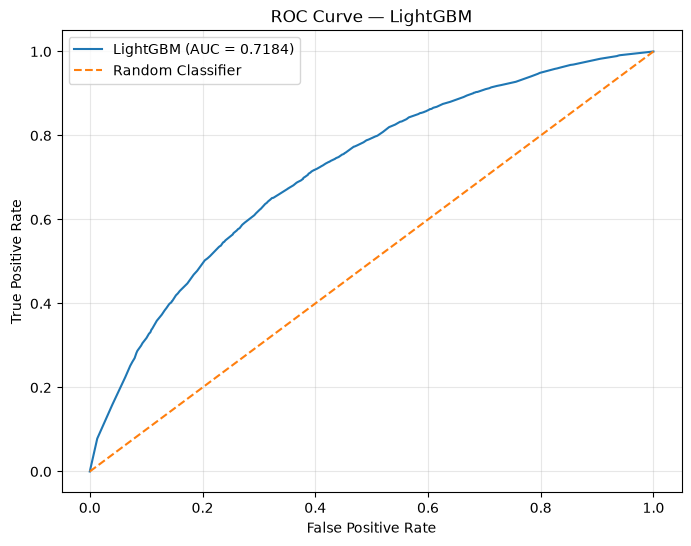

In [62]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_val,
    y_val_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"LightGBM (AUC = {val_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — LightGBM")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

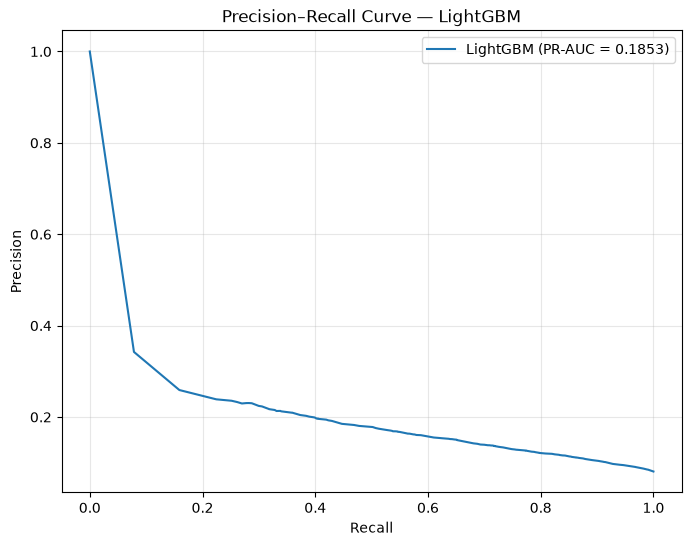

In [63]:
from sklearn.metrics import precision_recall_curve

precision, recall, pr_thresholds = precision_recall_curve(
    y_val,
    y_val_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"LightGBM (PR-AUC = {val_pr_auc:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — LightGBM")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Confusion Matrix:
[[56537     0]
 [ 4965     0]]


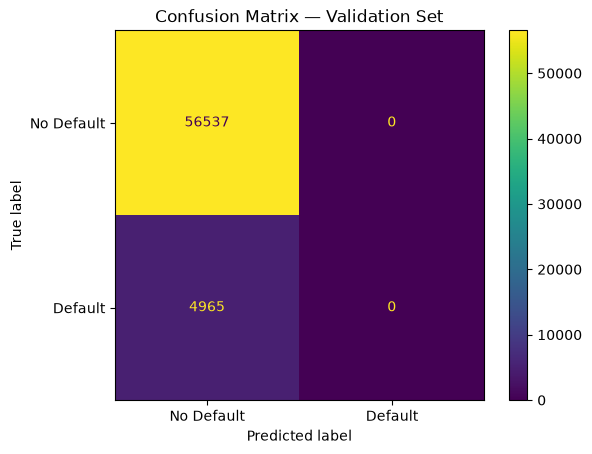

In [64]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_val_pred = (
    y_val_proba >= 0.5
).astype(int)

cm = confusion_matrix(
    y_val,
    y_val_pred
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Default", "Default"]
)

disp.plot()
plt.title("Confusion Matrix — Validation Set")
plt.show()

In [65]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=[
            "No Default",
            "Default"
        ]
    )
)

              precision    recall  f1-score   support

  No Default       0.92      1.00      0.96     56537
     Default       0.00      0.00      0.00      4965

    accuracy                           0.92     61502
   macro avg       0.46      0.50      0.48     61502
weighted avg       0.85      0.92      0.88     61502



/Users/arnav/Desktop/AI-Finance-Research/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/arnav/Desktop/AI-Finance-Research/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/arnav/Desktop/AI-Finance-Research/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

In [66]:
results = pd.DataFrame({
    "Experiment": [
        "Application Only",
        "Application + Bureau",
        "Application + Bureau + BB",
        "Application + Previous Applications",
        "Application + Previous + Installments",
        "Application + Previous + Installments + POS",
        "All Historical Sources",
        "Weighted LightGBM",
        "63-Leaf LightGBM",
        "100% Feature LightGBM",
        "Min Child Samples = 20",
        "Regularized LightGBM"
    ],

    "ROC-AUC": [
        0.763046,
        0.768690,
        0.767901,
        0.775064,
        0.776533,
        0.779164,
        0.781644,
        0.718384,
        0.781274,
        0.780175,
        0.780706,
        0.781424
    ],

    "PR-AUC": [
        0.255328,
        0.262631,
        0.263126,
        0.272123,
        0.274880,
        0.278727,
        0.280101,
        0.185339,
        0.280070,
        0.279303,
        0.279721,
        0.279951
    ]
})

results.sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

,Experiment,ROC-AUC,PR-AUC
0,All Historical Sources,0.781644,0.280101
1,Regularized LightGBM,0.781424,0.279951
2,63-Leaf LightGBM,0.781274,0.280070
3,Min Child Samples = 20,0.780706,0.279721
4,100% Feature LightGBM,0.780175,0.279303
5,Application + Previous + Installments + POS,0.779164,0.278727
6,Application + Previous + Installments,0.776533,0.274880
7,Application + Previous Applications,0.775064,0.272123
8,Application + Bureau,0.768690,0.262631
9,Application + Bureau + BB,0.767901,0.263126


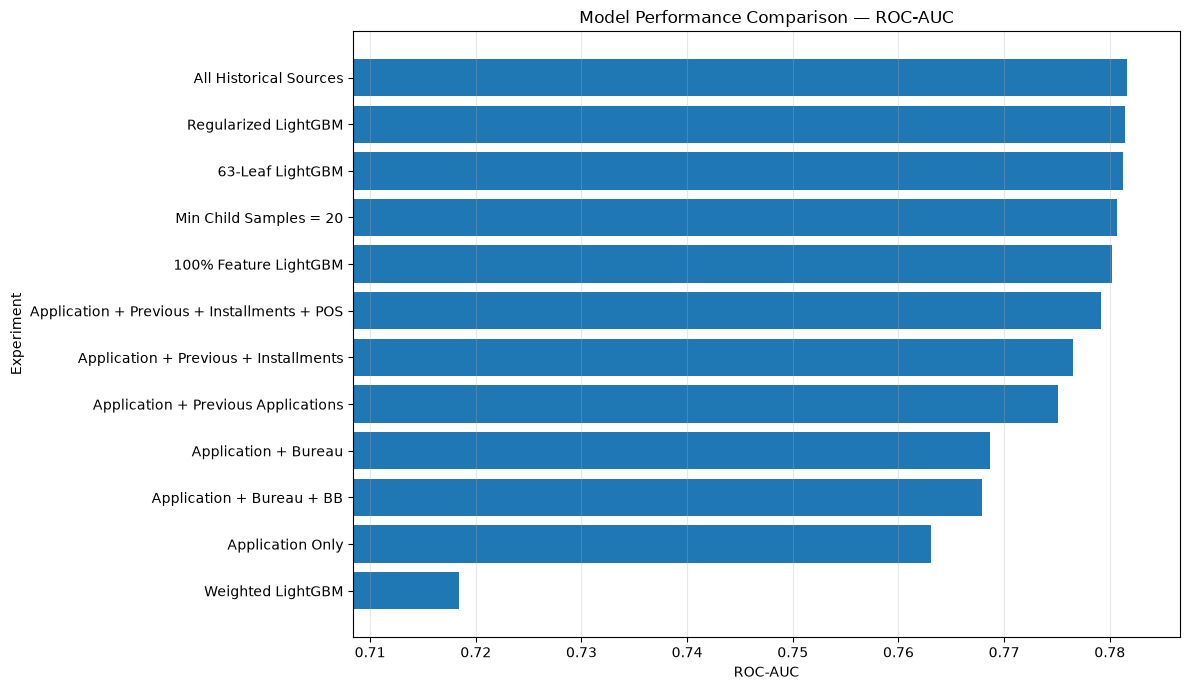

In [67]:
plt.figure(figsize=(12, 7))

plot_results = results.sort_values(
    "ROC-AUC",
    ascending=True
)

plt.barh(
    plot_results["Experiment"],
    plot_results["ROC-AUC"]
)

plt.xlabel("ROC-AUC")
plt.ylabel("Experiment")
plt.title("Model Performance Comparison — ROC-AUC")

plt.xlim(
    plot_results["ROC-AUC"].min() - 0.01,
    plot_results["ROC-AUC"].max() + 0.005
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

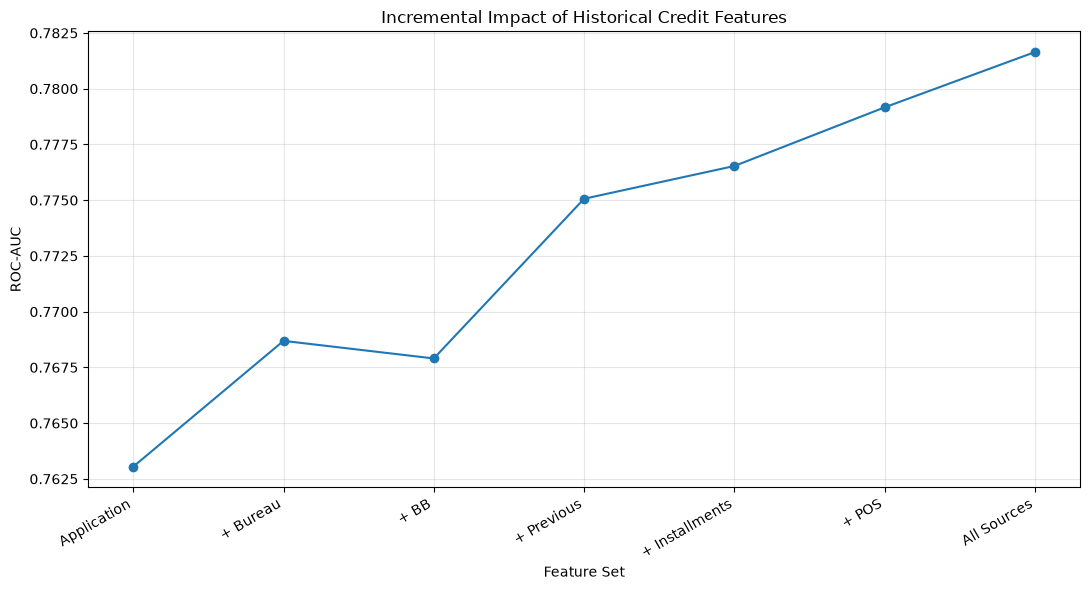

In [68]:
ablation_results = results.iloc[:7].copy()

plt.figure(figsize=(11, 6))

plt.plot(
    range(len(ablation_results)),
    ablation_results["ROC-AUC"],
    marker="o"
)

plt.xticks(
    range(len(ablation_results)),
    [
        "Application",
        "+ Bureau",
        "+ BB",
        "+ Previous",
        "+ Installments",
        "+ POS",
        "All Sources"
    ],
    rotation=30,
    ha="right"
)

plt.ylabel("ROC-AUC")
plt.xlabel("Feature Set")
plt.title("Incremental Impact of Historical Credit Features")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

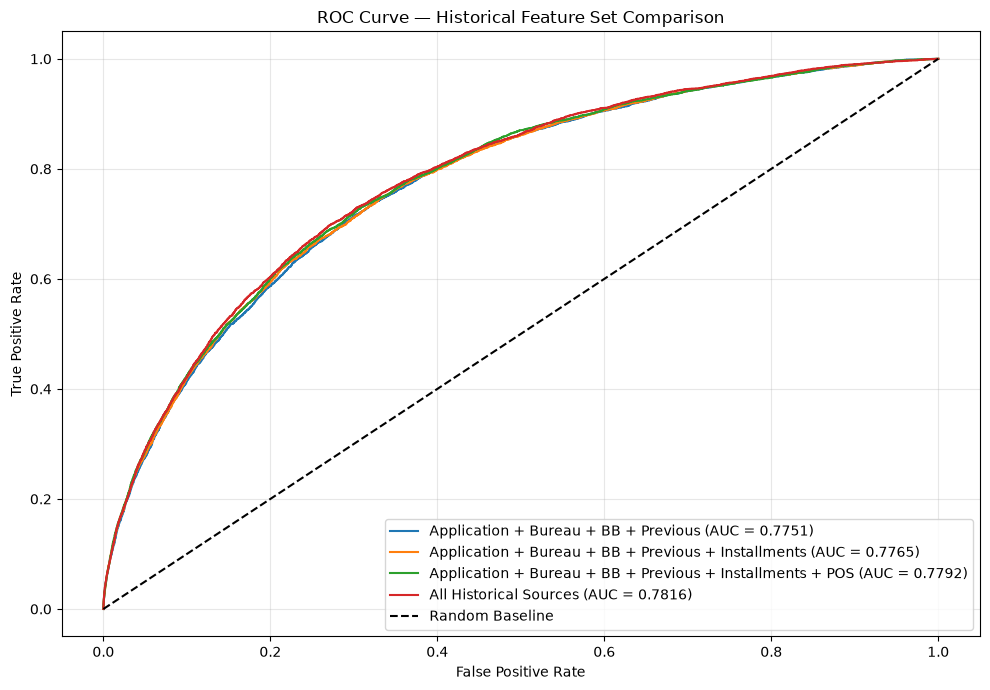

In [69]:
from sklearn.metrics import roc_curve, roc_auc_score

model_predictions = {
    "Application + Bureau + BB + Previous":
        y_val_app_bureau_bb_prev,

    "Application + Bureau + BB + Previous + Installments":
        y_val_app_bureau_bb_prev_inst,

    "Application + Bureau + BB + Previous + Installments + POS":
        y_val_app_bureau_bb_prev_inst_pos,

    "All Historical Sources":
        y_val_all
}

plt.figure(figsize=(10, 7))

for name, predictions in model_predictions.items():

    fpr, tpr, _ = roc_curve(
        y_val,
        predictions
    )

    auc_score = roc_auc_score(
        y_val,
        predictions
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random Baseline"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Historical Feature Set Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Conclusion — Model Development and Selection

The modelling experiments demonstrate that combining application-level information with historical credit behavior improves payment-difficulty prediction.

The Application-only LightGBM model achieved a ROC-AUC of **0.7630**. Adding historical information progressively improved performance, with the complete historical feature set achieving a ROC-AUC of **0.7816** and PR-AUC of **0.2801**.

The ablation analysis showed that **Previous Applications** provided the largest incremental improvement, while **Installment** and **POS Cash** information provided additional predictive value. Bureau Balance produced only a small change when added independently, but was retained as part of the complete historical feature set because feature groups can provide complementary information when combined.

Several LightGBM configurations were also evaluated. The unweighted 31-leaf model achieved the highest ROC-AUC (**0.7816**) among the tested configurations. The 63-leaf and regularized models produced extremely similar results, indicating that performance was relatively stable around the selected configuration.

Class weighting was also investigated. The weighted LightGBM model achieved only **0.7184 ROC-AUC** and **0.1853 PR-AUC**, substantially below the unweighted model. Therefore, class weighting was not used in the final model.

### Final Model

The final model is an **unweighted LightGBM classifier using the complete engineered feature set**.

- **Processed features:** 422
- **Training observations:** 184,506
- **Validation observations:** 61,502
- **ROC-AUC:** **0.7816**
- **PR-AUC:** **0.2801**
- **Best iteration:** **731**

The ROC and PR curves, feature-importance analysis, and feature-ablation experiments collectively show that historical repayment and credit behavior adds meaningful predictive information beyond the current loan application.

The model is therefore selected for final evaluation on the held-out test set.